# Chapter Summary

This chapter explains the concept of a sample space, outcomes and events, and the usage of the language of sets to express events.

It then shows how to "count" the number of outcomes or the size of a sample set in a variety of conditions, so that we can use this for the "naive" definition of probability which reduces to counting favorable outcomes vs the total outcomes in the sample space. The counting is discussed in the context of sampling and distribution. The multiplication rule for counting the result of multiple experiments in succession.

It then covers the modern, axiomatic definition of probability.

The problems and examples cover important problems that keep repeating in later chapters:

- Coins
- Cards
- Dice
- Jars
- Elks
- Binomial Theorem
- Bose-Einstein statistics
- The Birthday problem
- Teams
- Vandermonde's identity
- The Hockey-Stick identity
- Principle of Inclusion-Exclusion

## Sample Space and Event

A **sample space** S of an experiment is the set of all possible outcomes of the experiment. An **event** A is a subset of the sample space,  
and we say A occured if the actual outcome is in A.

In this sense, an experiment is just about anything you can do where there are one or more outcomes possible.



### Coin Flips

Coin is flipped 10 times. 

Sample Space: All strings of form HHHTTHTHTH - effectively $2^{10} = 1024$

How many possible events? Every possible subset of a set with $2^{10}$ elements = $2^{1024}$



### Pack of Cards

Pick a card from a pack: Sample Space size: 52

Events? $2^{52}$

## The Language of Sets

One can translate probabilities from English to the language of sets.


A sample space is a set S. If an experiment has a possible outcome s, then $s \in S$. If "A" is an event, then $A \subset S$. If the outcome of the experiment is $s_{actual}$, and event A has occured, then $s_{actual} \in A$. 

We can also combine events using the language of sets. Given two events A and B

- the event that either A or B or both occur is $A \cup B$
- That either A or B occur, but not both is $(A \cap B^{c}) \cup (A^{c} \cap B)$
- the event that both A and B occur is $A \cap B$
- at least one of $A_1, A_2,...,A_n$ occurs is the event $\bigcup_{i=1}^{n} A_i$
- all of $A_1, A_2,...,A_n$ occur together is the event $\bigcap_{i=1}^{n} A_i$

Or relationships between events:

- A implies B (whenever A occurs, B also occurs): $B \subset A$
- A and B are mutually exclusive $A \cap B = \emptyset$
- $A_1, A_2,...,A_n$ are mutually exclusive and exhaustive events (a partition) of S : $\bigcup_{i=1}^{n} A_i = S$ and $A_i \cap A_j = \emptyset, i \ne j$

## Naive Definition of Probability

$\displaystyle p_{naive} = \frac{|A|}{|S|}$


This relies of the assumption that every item in the set is **equally-likely** - an assumption for which usually there is no justification.

However, this may work when:

a) There is some **symmetry** in the problem - e.g a fair coin, or a well-shuffled deck of cards. Also cards have no agency, so we will not have self-selected cards eager to be at the top (unlike people for e.g.)

b) When outcomes are equally likely by **design** - e.g. in a well-designed survey when n people are picked randomly from a sample space of N. In practice this is usually imperfect.

c) As a **null model** - as something to test the actual outcomes against.

The Pebble World Metaphor: In the "naive" view of probability, a sample space is like a collection of pebbles, all of exactly the same size (mass).


# How to Count

## Multiplication Rule

Given an experiment composed of two sub-experiments with sample space S and S', the combined sample space will be $S \times S'$, with $|S||S'|$ outcomes.

Note that the chronological order of experiments in this case does not matter.

**Chessboard** There are 64 squares. How many black squares? 4 in each row, and there are 8 rows. So 8.4 (by the multiplication rule) - the experiment is: Pick a row, and within a row, pick black square.

**Runners** 10 people run a race. how many possibilities are there for the 1st, 2nd and 3rd place winners?

No of one-to-one functions from "3" to a set with 10 elements = $n!/(n-k)! = n.(n-1).(n-k+1) = 10.9.8$

1st - 10 possibilities  
2nd - 9 possibilities  
3rd - 8 possibilities  

By multiplication rule 10.9.8

But it works the other way too, even if it feels unnatural:

3rd - 10 possibilities  
2nd - 9 possibilities  
1st - 8 possibilities  


Note the subtlety here: the precise sample spaces will change, depending on who came 1st, 2nd etc. But the numbers are the same in this problem.

**Decision Tree with Ice Cream Cones**

Suppose you have 2 cones, 3 flavours. Then you have 2.3 = 6 possibilities. You can create a decision tree to show this process.

Suppose you had 2 cones - one morning, one evening. Then you have 6.6 = 36 possibilities. But if you are not interested in the order then how many do you have? Well you have 30 possibilities where the choices (x,y), $x \ne y$. and 6 choices with $(x,x)$ - so you are left with 15+6=21 choices. But these are **NOT equally likely**. So the 6 (x,x)'s have probability 1/36, the 15 (x,y)'s have probability 2/36. 

**Subsets** 

For any element we have 2 choices - include it or exclude it. Given n elements, that is $2^n$ choices




In [22]:
import matplotlib.pyplot as plt
import networkx as nx

def plot_tree_diagram(edges, title="Tree Diagram", figsize=(8, 5), node_color='lightgreen'):
    """
    Creates a hierarchical tree diagram and wraps node text at hyphens.
    """
    G = nx.DiGraph()
    G.add_edges_from(edges)
    
    # 1. Calculate tree layers for automated layout
    roots = [n for n, d in G.in_degree() if d == 0]
    if not roots:
        raise ValueError("The graph must have at least one root node.")
    
    for root in roots:
        depths = nx.single_source_shortest_path_length(G, root)
        for node, depth in depths.items():
            G.nodes[node]['layer'] = depth

    # 2. Position math (Top-Down layout)
    pos = nx.multipartite_layout(G, subset_key="layer", align="vertical")
    pos = {node: (-y, -x) for node, (x, y) in pos.items()}

    # 3. Create text-wrapped labels (replaces '-' with a newline '\n')
    wrapped_labels = {node: str(node).replace('-', '\n') for node in G.nodes()}

    # 4. Plotting
    fig, ax = plt.subplots(figsize=figsize)
    
    # Increased node size slightly to give text more breathing room
    nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=2200, ax=ax)
    nx.draw_networkx_edges(G, pos, arrows=True, edge_color='gray', arrowsize=15, ax=ax)
    
    # Pass the wrapped_labels dictionary to the labels argument
    nx.draw_networkx_labels(G, pos, labels=wrapped_labels, font_size=8, font_family='sans-serif', ax=ax)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()



## Decision Trees and The Multiplication Rule

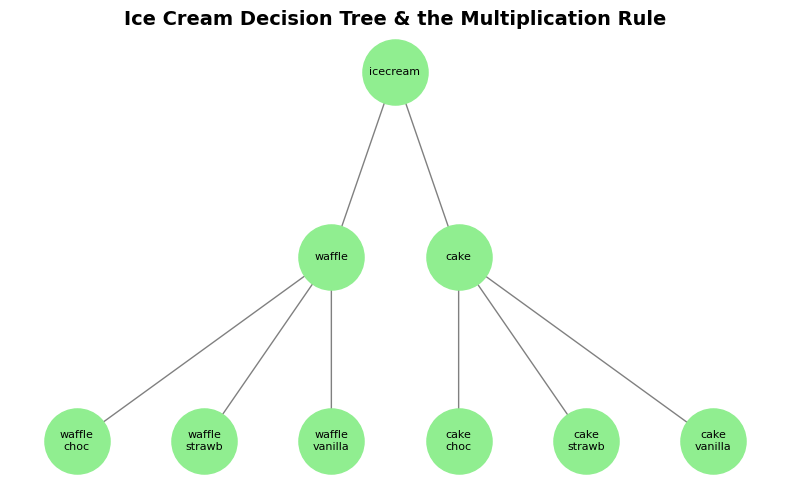

In [23]:
# Your original dataset
prod_edges = [
    ('icecream', 'waffle'), ('icecream', 'cake'),
    ('waffle', 'waffle-choc'), ('waffle', 'waffle-strawb'), ('waffle', 'waffle-vanilla'),
    ('cake', 'cake-choc'), ('cake', 'cake-strawb'), ('cake', 'cake-vanilla'),
]

# Run the function
plot_tree_diagram(
    edges=prod_edges, 
    title="Ice Cream Decision Tree & the Multiplication Rule"
)

## Sampling

### Sampling With Replacement, with Order ($n^k$)

If there are n objects, and we make k choices while replacing the object - i.e. it can be chosen again, then there are $n^k$ possible outcomes where order matters.

**Example**: No of functions from k to n.

**Example**: In many lotteries numbered balls are chosen from 0..9, and then replaced before being picked for the next digit. If the lottery had 8 digits, then the possible choices are $10^8$, as is to be expected, where k=10, n=8. Note that order matters, because a different order would be a different lottery number.

**Decision Tree / Multiplication Rule** : Basically here we have a k-level decision tree, where at each level i, we have $n^i$ nodes.


### Sampling Without Replacement, with Order: ($\frac{n!}{(n-k)!}$)

If there are n objects, and we make k choices without replacement - i.e. it once chosen, it cannot be chosen again, then there are $\frac{n!}{n-k!}$ possible outcomes where order matters.

**Example**: No of one-one functions from k to n.

**Example**: From a pool of 10 runners, 5 are selected (without replacement), one for e and assigned to a lane. 

Note that it is necessary that $k \le n$

**Decision Tree / Multiplication Rule**: Here is a tree with k levels. Nodes at level i have (n-i) children, taking the top level to i=0, leading to a total of n(n-1)(n-2)...(n-k+1) nodes at the leaf.

In [28]:
from math import perm

# Calculate permutations for 10 items picked 3 at a time
result = perm(10, 3)
print(result)  # Output: 720


720


**No of Permutations of n objects: ($n!$): No of bijective functions from n to n.**

Taking the sampling without replacement approach, we get n.(n-1)....1 = n!.

This is just a special case of the sampling without replacement where k = n.

e.g. Assign 5 people to 5 seats in a car.


### Sampling without Replacement, without Order: $\binom{n}{k} = \frac{n!}{n-k!k!}$ - No of k-element subsets.

We can choose k people from n, without replacement in $\frac{n!}{n-k!}$ ways. 

Adjusting for overcounting: Since we have chosen k people, and we can order k people in k! ways, by dividing by k! we get $\binom{n}{k} = \frac{n!}{n-k!k!}$ as the no of ways to choose k elements from a set of n, without order.

**Decision Tree** : If we are building a decision tree, we can enforce lexicographic ordering to eliminate duplicate orders. Basically only allow children which are lexicographically higher than the parent, eliminating duplicate paths. Since there is no replacement, every element of the path is unique, and we know we can reorder each k-length path in in k! ways (See previous section) i.e. we each path represents one of k! paths when order was important.  

In [26]:
from math import comb

# Calculate 10 choose 3
result = comb(10, 3)
print(result)  # Output: 120

from scipy.special import binom

result = binom(10, 3)
print(result)  # Output: 120.0

120
120.0


**Sample all subsets of a set: $2^n = \binom{n}{0} + \binom{n}{1} + \dots + \binom{n}{n}$**

Sampling all subsets implies sampling 0,1,..n elements from an n-element subset, without regard to order.

Note that it is equal to the count of all functions from n to 2 -> this is because given a set X, for every subset A there is a characteristic function $\chi_A:X \to A$ which assigns a 1 or 0 to an elements based on whether it is in A or not.

**Binomial Theorem: $(a + b)^n = \binom{n}{0}a^n + \binom{n}{1}a^{n-1}b + \dots + \binom{n}{n}b^n = \sum\limits_{i=0}^{n} \binom{n}{i} a^{n-i}b^i$**

This theorem is based on counting how many ways can we choose a's and b's : given k a's (and hence n-k b's), we have $\binom{n}{k}$ ways the coefficient of $a^{n-k}b^{k}$ will be chosen.


### Sampling with Replacement, without Order: $\binom{n+k-1}{k} = \binom{n+k-1}{n-1}$

We can draw the following **stars and bars** diagram where n=4, k=7

$$\text{| * * | * | * * | * * |}$$

**Example**: We have 4 menu items and we have to order 7 items in all (sampling with replacement). We just need to know how many of each item we are ordering, which can be anything from 0 to 7. The diagram about has n+k+1 places, but the 2 bars at either end are fixed, leaving n+k-1 slots for 3 (n-1) bars or 7 (k) stars. 


## Sampling with Grouping / Repetition

**Multinomial Coefficient $\binom{n}{k_1,k_2,k_3}$**

The term $\frac{n!}{k_1!k_2!k_3!}$ is called the multinomial coefficient.

**Adjusting for Overcounting: Permutations with Repetition: $\frac{n!}{k_1!k_2!k_3!}$**

Given a word like STATISTICS, how many permutations are possible? There are 10 letters, so we can say it is $10!$. But we have 3 S's, 3 T's, and 2 I's, 1 A, and 1 C. So adjusting for overcounting, we get: 

$$\frac{10!}{3!3!2!1!1!}$$ 

**Grouping where order within groups does not matter**

Suppose we have to select 3 teams A,B,C from 14 people, of 4,5 and 5 people each. How many ways can we do this?

One way to think of this is - line up all the people in order: 14! ways (Sampling without replacement)

Assign first four to Team A, the next 5 to Team B and then the last 5 to Team C. We are overcounting by 4!5!5! ways, because the order within the group does not matter.

Ans: $\binom{14}{2,5,5}$

**Grouping where order within groups does not matter, and groups with same size are identical**

Taking the example above, suppose the 2 groups of 5 are considered identical. Then all permutations of these groups are repeated and need to be pruned from the decision tree.

Ans: $\binom{14}{2,5,5}\frac{1}{2!}$


**Sampling with Replacement, no ordering, but with a limit**

Suppose I am allowed to sample k items from n, with replacement (order is not important), but with a limit of c per item. 

We start with ignoring the limit : Total number of ways = $\binom{n+k-1}{k}$

Now we have to remove all items where there is (at least one violator): A violator has at least c+1 items. 
We can choose a violator in n ways, and then assume at least c+1=d items. And then we choose (with repetition) from n items the remaining k-d items. So we have $(-1)\binom{n}{1}\binom{n+k-d-1}{k-d}$. However suppose $n_1$ and $n_2$ are 2 violators in one sample, these will be double-counted: So we have to add back : $\binom{n}{2}\binom{n+k-2d-1}{k-2d}$ - using this **inclusion-exclusion** principle, we get:

$$Count = \sum_{j=0}^{n} (-1)^j \binom{n}{j}\binom{n+k-j(c+1)-1}{k-j(c+1)}$$

Note that once j(c+1) > n, the term will become zero - this is logical : No of violaters (j) cannot exceed $\frac{n}{c+1}$

## Distributions

Distribution problems are also known as occupancy problems. It is essentially the problem of allocating k items in n containers, with differences in whether (a) the items are distinct or (b) the containers are distinct or (c) other constraints e.g. how many items per container.

Sampling problems are a task of extracting k elements from n items. The choices are to do this with or without replacement, with order being important or not.

Distribution and Sampling problems can overlap, but there are distribution problems which do not translate to sampling problems.

### k Identical items distributed in n distinct containers: $\binom{n+k-1}{k} = \binom{n+k-1}{n-1}$

This is the distribution counterpart of sampling n distinct items k times with replacement.

**Bose-Einstein: Putting k indistinguishable particles in n distinguishable boxes**


Simply speaking we just line up the elements, and the partitions between boxes. Since the first and last partitions are fixed, we have (n-1) partitions and k elements, making a total on n+k-1 slots in all, excluding the ends. So the problem boils down to : put the k particles in (n+k-1) slots. Then put the partitions wherever a slot is free, giving $\binom{n+k-1}{k}$ choices.

This is very rarely used, but is important in Quantum Mechanics.

**No container empty**

Here k >= n. First distribute n items in each of the boxes. Then the remaining k-n particles are distributed among the n boxes in:


$$\binom{n + k - n - 1}{k-n} = \binom{k - 1}{k-n} = \binom{k - 1}{k-1 - k + n} = \binom{k - 1}{n - 1}$$


### k distinct items distributed in n distinct containers : ($n^k$)

Imagine k toys (a car, a truck, a horse) in n boxes (red, blue)

In sampling terms, suppose we sample from the set {red, blue} 3 times (once for each toy). This is sampling with replacement, where order matters. So number of choices are : $n^k$


### k distinct items distributed in n distinct containers (max 1): ($P(n,k)$)


This can be seen as a sampling problem in this way: Out of n containers, we sample k without replacement, one for each of the k items. This, as we know is P(n,k)


$$
\renewcommand{\stirling}{\genfrac\{\}{0pt}{}}
$$

### n distinct items in k identical containers

Here the identity of the container does not matter. So this is simply asking how one can partition n distinct items into k partitions. The reason for reversing n & k here is just convention - Stirling numbers are expressed in terms of k-partitions.

**Scenario 1: No container empty $S(n,k), \stirling{n}{k}$**

$$S(n,k) = \frac{1}{k!}\sum\limits_{i=0}^{k} (-1)^i \binom{k}{i} (k-i)^n$$

**Scenario 2: Empty containers allowed**

$$\sum_{i=1}^{k} S(n,i)$$

As a special case, if $k \ge n$, then the number is the bell no: $B_n = \sum_{i=1}^{n} S(n,i)$


### n identical items in k identical containers

In this case even the grouping doesn't matter, just the count. This reduces the problem to one of integer partitioning - the number of ways to express an integer as a sum of positive integers.

There is no simple expression for this number, just a recurrence relation.

$$P(n,k) = P(n-1,k-1) + P(n-k,k)$$

<div class="alert alert-block alert-info">
<h2>Ex 1.4.10 : Birthday problem</h2>

Given k people in a room, what is the probability that at least 2 people have the same birthday? Assume birthdays of people are independent and any day of the year is equally likely.

Ans:

$\displaystyle P(\text{no birthday match}) = \frac{365.364.\dots.365-k+1}{365.365.\dots.365}$

$\displaystyle P(\text{birthday match}) = 1 - \frac{365.364.\dots.365-k+1}{365.365.\dots.365}$

$\displaystyle P(\text{no birthday match}) = \frac{P(n,k)}{n^k}$

Note: For the event - we count by sampling the days of the year without replacement, ordered, while the denominator is calculated by sampling with replacement, ordered. 
</div>


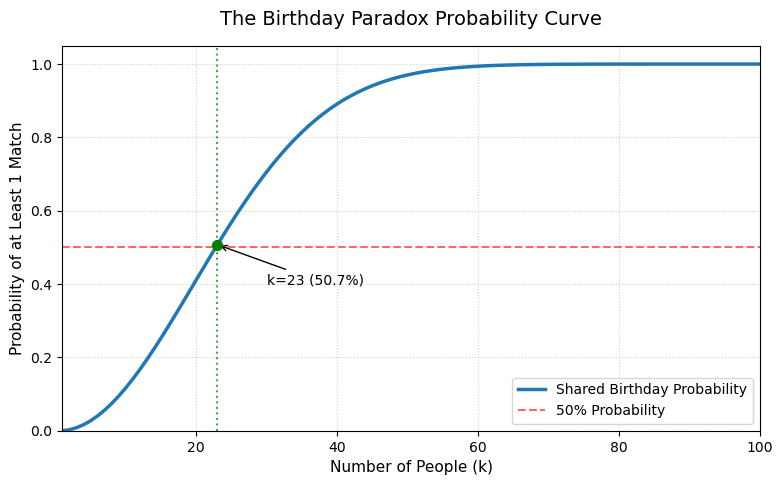

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Compute the probabilities using the optimized NumPy code
k_values = np.arange(1, 101)
numerators = 365 - np.arange(100)
prob_shared = 1.0 - np.cumprod(numerators / 365.0)

# 2. Initialize the plot figure
plt.figure(figsize=(9, 5))

# 3. Plot the main probability curve
plt.plot(k_values, prob_shared, color='#1f77b4', linewidth=2.5, label='Shared Birthday Probability')

# 4. Add visual anchors for the 50% breakthrough (k=23)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.6, label='50% Probability')
plt.axvline(x=23, color='green', linestyle=':', alpha=0.7)
plt.scatter(23, prob_shared[22], color='green', s=50, zorder=5) 
plt.annotate(f'k=23 ({prob_shared[22]:.1%})', 
             xy=(23, prob_shared[22]), 
             xytext=(30, 0.4),
             arrowprops=dict(arrowstyle="->", color='black'))

# 5. Label axes and clean up formatting
plt.title('The Birthday Paradox Probability Curve', fontsize=14, pad=15)
plt.xlabel('Number of People (k)', fontsize=11)
plt.ylabel('Probability of at Least 1 Match', fontsize=11)
plt.xlim(1, 100)
plt.ylim(0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

# 6. Render the window
plt.show()


## Example 1.4.20: Probability of a Full-House in Poker

A full house (in a 5-card hand) is when we have 3 cards of one rank, and 2 of another.

By multiplication rule we have:

(13 ways for first rank) x (choosing 3 cards out of 4) x (12 ways for second rank) x (choosing 2 out of 4)

The 2 ranks are chosen using "sampling with replacement, ordered": $P(13,2)$. The ordering is because the 2 ranks are different - the first rank would have 3 cards, the second rank with 2 cards. As an aside, if a full house was 2 cards each, the ordering would be unnecessary.

The 3 cards are chosen using "sampling without replacement, unordered": $\binom{4}{3}$, and the 2 are chosen with: $\binom{4}{2}$

All possible ways to choose 5 cards (unordered) from 


Thus:

$P(\text{full house}) = P(13,2)\frac{\binom{4}{3}\binom{4}{2}}{\binom{52}{5}}$

In [50]:
from math import comb, perm

print(round(100*perm(13,2)*binom(4,3)*binom(4,2)/binom(52,5), 4))

0.1441


# Story Proofs


<div class="alert alert-block alert-info">
<h2>Ex 1.5.1 (Choosing the complement): $\binom{n}{k} = \binom{n}{n-k}$</h2>

Having chosen k elements from n (without ordering), as in the left side, i have also chosen the remaining (n-k) elements, which is the right side.
</div>

## Ex 1.5.2 (The team captain): $n\binom{n-1}{k-1} = k\binom{n}{k}$

I need to choose k people for a team, including one captain. 

I can choose a captain first in n ways, and then k-1 people from the remaining n-1 in $\binom{n-1}{k-1}$ ways (left side), or I can choose the k people first in $\binom{n}{k}$ ways, and designate one of them as the team captain in k ways (right side).

<div class="alert alert-block alert-info">
<h2>Ex 1.5.3: (Vandermonde's Identity): $\binom{m+n}{k} = \sum\limits_{j=0}^{k} \binom{m}{j}\binom{n}{k-j}$</h2>

I have m senior and n junior members. I need to form a board with k people. 

I can choose k people from m+n (left side). Or

I can choose j juniors and then k-j seniors, j ranging from 0 to k, the right side.
</div>

## Ex 1.5.4 (Partnerships): $\frac{2n!}{2^n.n!} = (2n-1)(2n-3)\dots.3.1$

I want to pick pairs of people from a group, so i just randomly order them, then pick pairs in order - giving 2n! ways. But order within a pair does not matter, and order of the n pairs does not matter, so adjusting i get the left side.

Alternatively (remembering order does not matter), i can choose 2n-1 people as partner for person 1. For the next unpaired person (2 or 3), we have 2n-3 choices, and so on, till the last person has one choice.

# Non-naive Definition of Probability

**Definition: General Definition of Probability**

A probability space consists of a sample space S, and function $P:P(S) \to [0,1]_R$ such that:

a) $P(\emptyset)$ = 0

b) If $A_1, A_2, \dots$ are disjoint events, then

$$P(\bigcup\limits_{i=1}^{n} A_i) = \sum\limits_{i=1}^{n} P(A_i)$$

In "Pebble world" probability behaves like mass. Mass of an empty pile is zero, of all pebbles is 1. If we take non-overlapping piles of pebbles, their masses add up to the whole. 

Unlike the naive case, now pebbles can have different masses.

Also, now we can consider countably infinite number of masses, as long as their masses add up to 1.

We can even have uncountable sample spaces : visualize mud spread out over a region with total mass 1, instead of pebbles. 

## Theorem 1.6.2: Properties of Probability

1. $P(A^c) = 1 - P(A)$
2. If $A \subset B$, then $P(A) \le P(B)$
3. $A \cup B = P(A) + P(B) - P(A \cap B)$


## Proof

**Prop 1)**

$S = A \cup A^c$, by definition  
$P(S) = P(A \cup A^c) = 1$  
But A and $A^c$ are disjoint. So $P(A \cup A^c) = P(A) + P(A^c) = 1$. 

**Prop 2)**  
$P(A \cup (B-A)) = P(A) + P(B-A) = P(B)$. Hence: $P(A) = P(B) - P(B-A) \implies P(A) \le P(B)$, since $P(B-A) \ge 0$

**Prop 3)**  
$A \cup B = A \cup (B \cap A^c)$ which are disjoint.

Hence, $P(A \cup B) = P(A \cup (B \cap A^c)) = P(A) + P(B \cap A^c)$

But $P((A \cap B) \cup (B \cap A^c)) = P(B) = P(A \cap B) + P(B \cap A^c)$. It follows that:

$P(B \cap A^c) = P(B) - P(A \cap B)$


## Theorem (Principle of Inclusion-Exclusion): For any events $A_1, A_2, \dots, A_n$

$P(\bigcup\limits_{i=1}^{n} A_i) = \sum_i P(A_i) - \sum_{i < j} P(A_i \cap A_j) + \sum_{i < j < k} P(A_i \cap A_j \cap A_k) + \dots + (-1)^{n+1} P(A_1 \cap A_2 \cap \dots \cap A_n)$

<div class="alert alert-block alert-info">

<h2>Ex 1.6.4: (de Montmort's Matching Problem)</h2>

Flip n well-shuffled numbered cards (numbered from 1 to n) over, while speaking aloud the number in sequence. You win if any time the card has the same number you are speaking.

$A_i$ is the probability that the ith card has the number i written. 

Clearly $P(A_i) = \frac{1}{n}$ - by symmetry. 

$P(A_i \cap A_j) = \frac{1}{n(n-1)}$ - since i,j fixed, we have $(n-2)!$ arrangements out of $n!$


$P(A_i \cap A_j \cap A_k) = \frac{1}{n(n-1)(n-2)}$ - and so on.

By inclusion-exclusion principle:

$P(\bigcup\limits_{i=1}^{n} A_i) = \binom{n}{1}\frac{1}{n} - \binom{n}{2}\frac{1}{n(n-1)} + \dots + (-1)^{n+1}\binom{n}{n}\frac{1}{n!} = 1 - \frac{1}{2!} + \dots + (-1)^{n+1}\frac{1}{n!} \approx 1 - \frac{1}{e}$

</div>


## References

[Gorroochurn - Errors in Probability](https://www.columbia.edu/~pg2113/index_files/Gorroochurn-Best%20Writings%20on%20Mathematics.pdf)

# Exercise 1.9 - Counting

1. Permutations: MISSISSIPPI - 1M, 2P, 4S, 4I : $\frac{11!}{2!4!4!}$

2. How many 7 digit phone nos  
a) Assuming first digit cannot be 0 or 1: $10^7 - 2.10^6 = 8.10^6 = 8000000$  
b) Assuming also it cannot start with 911: $10^7 - 2.10^6 - 1.10^4 = 8000000 - 10000 = 7990000$

3. Fred's 10 restaurants:  
a) Schedule for Mon-Fri, each restaurant once only: (Sampling without replacement, order matters): $10.9.8.7.6$  
b) Schedule for Mon-Fri, each restaurant possibly more than once, but not consecutive:  $10.9.9.9.9$

4. Round-robin with n players.  
a) How many outcomes: $2.\binom{n}{2}$:  
b) How many games: $\binom{n}{2}$

5. Knock-out with $2^n$ players.  
a) How many rounds: 2^n, 2^{n-1}, ... 2^1 = n rounds.  
b) How many games: $2^{n-1} + 2^{n-2} + \dots + 1 = 2^n - 1$  
c) How many games in total - with little calculation: Every game eliminates one player. All but one player is eliminated.

6. 20 chess players - matched up, who plays white matters: $\frac{20!}{10!}$. Did not divide by $2^{10}$, as order within pair matters.

7. 2 chess players playing 7 games. win - 1, draw - 0.5.  
Total outcomes (order matters): $3^7$  
a) A ends up with 3w, 2d, 2l: $\binom{7}{3}.\binom{4}{2}$  
b) A ends up with 4, B ends up with 3 points: = 1wd6,2w4d1l,3w2d2l,4w3l = $\binom{7}{1} + \binom{7}{2}\binom{5}{4} + \binom{7}{3}\binom{4}{2} + \binom{7}{4}$  
c) Match ends in 7 games, with A winning by 4 to 3.  
Only choices after 6 games are i) A=3.5,B=2.5 and A draws or ii) A=3,B=3, and A wins.  

Options for A = 3.5 after 6: 3w1d, 2w3d, 1w5d = $\binom{6}{3}.\binom{3}{1} + \binom{6}{2}.\binom{4}{3} + \binom{6}{1} = 20.3 + 15.4 + 6 = 126$  
Options for A = 3 after 6: 3w, 2w2d, 1w4d, 0w6d = $\binom{6}{3} + \binom{6}{2}.\binom{4}{2} + \binom{6}{1}.\binom{5}{4} + \binom{6}{6} = 20 + 15.6 + 6.5 + 1 = 141$  

Alternatively: 3w(0d or 1d),2w(2d or 3d),1w(4d or 5d), or 0w6d = $(1+3).\binom{6}{3} + (6+4).\binom{6}{2} + (5+1).\binom{6}{1} + \binom{6}{6}  = 20.4 + 15.10 + 6.6 + 1 = 267$.

8. (Problem) (a) How many ways are there to split a dozen people into 3 teams, where one team has 2 people, and the other two teams have 5 people each?
(b) How many ways are there to split a dozen people into 3 teams, where each team has 4 people?


The challenge here is that the 2 5-member teams are not distinct i.e. switching the team members is the same combination. 



a) Split 12 people into 3 teams, one team of 2, other two of 5 each. $\binom{12}{2}\binom{10}{5} = 6.11.2.9.7.2 = 16632$  
b) Each team has 4: $\binom{12}{4}\binom{8}{4} = 11.10.9.7.5 = 34650$

ABOVE IS WRONG - as order of selecting team does not matter. 
a) In the first case we have overcounted the 5-member teams. We may end up with 2 same 5-member team pairs, e.g (a1,a2,a3,a4,a5)+(b1,b2,b3,b4,b5) OR (b1,b2,b3,b4,b5)+(a1,a2,a3,a4,a5), which is irrelevant. So answer is 16632/2 = 8316.

Better way is to think in terms of complete ordering and adjustment. Line up 12 people, select first 2 for team 1, next 5 for team 2, last 5 for team 3. Order within teams does not matter. But also, order of the two 5 member teams is interchangable just as above. So we have: $\frac{12!}{2!5!5!2!}$. The subtlety is that order between teams matters for teams of the SAME SIZE ONLY.

b) In second case we are overcounting by 3! = 6, since all teams are interchangable. So answer is 34650/6 = 5775. Or $\frac{12!}{4!4!4!3!}$

9. PATHS
a) How many paths from (0,0) to (110,111) such that each step consists of going one unit up or one unit right.  
Totally 110 right, 111 up, order does not matter. Out of 221 steps, i have to choose a 110 = $\binom{221}{110}$  

b) How many paths from (0,0) to (210,211), given path has to go through (110,111).  
(210,211) - (110,111) = (100,100). So $\binom{200}{100}$. Ans. $\binom{221}{110}.\binom{200}{100}$


**10)** 20 courses of which 5 are statistics courses. Student takes 7 out of 20 courses, but at least one needs to be a statistics course.

$\sum_{i=1}^{5} \binom{5}{i}\binom{15}{7-i} = \sum_{i=0}^{5} \binom{5}{i}\binom{15}{7-i} - \binom{15}{7} = \binom{20}{7} - \binom{15}{7}$


**11)** Let A and B be sets where |A| = m and |B| = n. How many functions are there from A to B? How many one-one functions?

A function is assigning one element of B to each element of A. How many ways can we sample m times from n elements with replacement (order is important)? Ans: $n^m$

One-One functions: Sample m times, without replacement. P(n,m). Note that if m > n, the answer is zero.

**12)** 4 people A,B,C,D are distributed 13 cards each.

a) How many different hands can A get? Ans: $\binom{52}{13}$

b) Total number of distributions, given who gets which hand matters: $\binom{52}{13,13,13,13} = \binom{52}{13}\binom{39}{13}\binom{26}{13}\binom{13}{13}$

c) We cannot have $\binom{52}{13}^4$ as the answer to (b), because we are sampling without replacement.

**13)** 10 deck of cards mixed (520 cards). 

a) how many ways can you deal 10 cards

Sampling 10 cards with replacement, order not important. $\binom{52+10-1}{10} = \binom{61}{10}$



**14)** You are ordering two pizzas. (S,M,L,XL) (8 toppings)

How many ways? 

0-8 toppings can be combined in how may ways? 2^8 = 256 * 4 sizes = 1024 choices.

Pick 2 pizzas with replacement, without ordering: $\binom{1024+2-1}{2} = \binom{1025}{2} = 524800$

# Exercises - Story Proof

**(15)$\sum_{k=0}^{n} \binom{n}{k} = 2^n$**

Both represent all possible subsets of a set of size n.

RHS: $2^n$ is the set of all n-bit binary sequences. We can see that each sequence represents a subset of n i.e. whether a number is in the subset or not. So it is the size of the power set of n.

LHS: In how many ways can i pick 0,1,2...n elements from a set of n elements? This also counts the number of 0 + 1 + 2 + ... + n element subsets of n i.e. all subsets of n.

**(16) $\binom{n}{k} + \binom{n}{k-1} = \binom{n+1}{k}$**

I have n people and 1 captain. I need to choose k people for some work.

(left side): I avoid the captain, and choose k people from n, or i take the captain, and k-1 people from the remaining n.

(right side): I take k people from (n+1)

**(17) $\sum_{k=0}^{n} \binom{n}{k}^2 = \binom{2n}{n}$**

Note: $\binom{n}{k} = \binom{n}{n-k}$

I have 2 groups of n people.

(right side): Choose n from 2n people  
(left side): Choose k from one group, n-k from the other, k = 0..n

**(18) $\sum_{k=1}^{n} k\binom{n}{k}^2 = n\binom{2n-1}{n-1}$**

I have n senior + n junior people. I want to select a team of n people, of which one is a captain who can only be senior.

RHS: I select one of the n seniors as captain, then select n-1 people from the remaining 2n-1

LHS: I can select k seniors ($\binom{n}{k}$ ways) and n-k juniors ($\binom{n}{n-k} = \binom{n}{k}$ ways).  So totally $\binom{n}{k}^2$ ways. k = 1 ... n: k >= 1 because at least one senior is needed. Now, i can select one of the k seniors as captain, so i get $k\binom{n}{k}^2$ ways i can get k seniors and n-k juniors in the team. Adding up on k, i get LHS.

**(19) $\sum_{k=2}^{n} \binom{k}{2}\binom{n -k + 1}{2} = \binom{n+3}{5}$**

As given in the hint: If we select any 5 different numbers from 1,2,..n+3, and order them, the middle number will be in the range (3..n+1). So this number splits the selection into two parts.

RHS: Select 5 people from n+3, n >= 2.

LHS: Suppose center number is k+1 (k>=2, k<=n). Then we get k numbers below the center, from which we pick 2, and (n+3-k-1) = (n-k+2) elements greater than the center from which we pick 2 elements. Adding up on k=2..n, we get another way to select 5 people.

**(20a) (Hockey-stick Identity) $\binom{k}{k} + \binom{k+1}{k} + \dots \binom{n}{k} = \binom{n+1}{k+1}$**

The hockey stick identity: (https://en.wikipedia.org/wiki/Hockey-stick_identity) - see why it looks like a hockey stick.

RHS: Select k+1 people from n+1

LHS: Number people from 1..n+1. Now, in each selection of k+1, the oldest can range from k+1 to n+1, and the remaining k can be selected from sets of first k,k+1,...n remaining people. Adding up gives the LHS, which is another way of selecting the k+1 people.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def generate_pascals_triangle(n):
    triangle = []
    for line in range(n):
        row = []
        for i in range(line + 1):
            if i == 0 or i == line:
                row.append(1)
            else:
                row.append(triangle[line - 1][i - 1] + triangle[line - 1][i])
        triangle.append(row)
    return triangle

# Configuration
n_rows = 6
start_row = 2
start_col = 2
triangle = generate_pascals_triangle(n_rows)

# Setup a more balanced figure size
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_facecolor('#f7f7f7')

# Crucial fix: Forces 1 unit horizontally to equal 1 unit vertically
ax.set_aspect('equal')

# Positioning constants for tighter packing
# Using standard equilateral triangle math: height = width * sqrt(3)/2 ~ 0.866
row_spacing = 0.866  
circle_radius = 0.45

# 1. Plot the base triangle
for row_idx, row in enumerate(triangle):
    # Shift each row left by 0.5 units multiplied by row index to center it
    x_start = -row_idx * 0.5
    y = -row_idx * row_spacing
    
    for col_idx, val in enumerate(row):
        x = x_start + col_idx
        
        circle = plt.Circle((x, y), circle_radius, facecolor='white', edgecolor='#cccccc', linewidth=1.5)
        ax.add_patch(circle)
        ax.text(x, y, str(val), ha='center', va='center', fontsize=11, fontweight='bold', color='#333333')

# 2. Pre-calculate hockey stick coordinates
stick_len = n_rows - start_row
frames_data = []
running_sum = 0

for i in range(stick_len):
    r = start_row + i
    c = start_col
    x = (-r * 0.5) + c
    y = -r * row_spacing
    running_sum += triangle[r][c]
    frames_data.append(('stick', x, y, triangle[r][c]))

# Add the final bend (the sum handle)
br = start_row + stick_len
bc = start_col + 1
bx = (-br * 0.5) + bc
by = -br * row_spacing
frames_data.append(('bend', bx, by, running_sum))

# Animation logic
def update(frame):
    if frame < len(frames_data):
        ftype, x, y, val = frames_data[frame]
        if ftype == 'stick':
            color, border = '#ffcccc', '#cc0000'
        else:
            color, border = '#ccffcc', '#009900'
            
        circle = plt.Circle((x, y), circle_radius, facecolor=color, edgecolor=border, linewidth=2.5)
        ax.add_patch(circle)
        ax.text(x, y, str(val), ha='center', va='center', fontsize=11, fontweight='bold', color=border)
    return []

# Dynamic limits based on triangle width and height to remove dead space
ax.set_xlim(-n_rows * 0.6, n_rows * 0.6)
ax.set_ylim(-n_rows * row_spacing - 0.5, 0.7)
ax.axis('off')
plt.title("Animating the Hockey Stick Identity", fontsize=14, pad=10)

# Build and display animation widget
ani = FuncAnimation(fig, update, frames=len(frames_data), interval=800, blit=True, repeat=False)
plt.close() 
HTML(ani.to_jshtml())



**(20b)Pack of gummi bears: 30-50. 5 flavours: p,r,o,s,l. How many combinations are possible?**

$30 \le x_1 + x_2 + x_3 + x_4 + x_5 \le 50$. Hence we see the number of combinations:

$$
\begin{aligned}
comb &= \sum_{j=30}^{50} \binom{5 + j - 1}{j} \\
     &= \sum_{j=30}^{50} \binom{j + 4}{j} \\
     &= \sum_{j=30}^{50} \binom{j + 4}{4} \\
     &= \sum_{j=34}^{54} \binom{j}{4} \text{   ... not quite a hockey stick}\\
     &= \sum_{j=4}^{54} \binom{j}{4} - \sum_{j=4}^{33} \binom{j}{4} \text{  ... but a difference of 2 hockey sticks}\\
     &= \binom{55}{5} - \binom{34}{5}
\end{aligned}
$$








**21: $\stirling{n}{k}$ - ways to partition n into k non-empty subsets.**


Prove: $\stirling{n+1}{k} = \stirling{n}{k-1} + k\stirling{n}{k}$. 

Basically: either the new (n+1th) element is an existing group (k possibilities), or existing n elements are in k-1 groups, and i create a new kth group for the n+1st element.

Prove: $\sum_{j=k}^{n} \binom{n}{j} \stirling{j}{k} = \stirling{n+1}{k+1}$. 

RHS: k+1 non-empty partitions of n+1 elements.

LHS: We are still figuring out how to create k+1 partitions of n+1 elements. We label one element, say A, and consider it's partition as the k+1st partition. Note that this "selection" does not affect the number of partitions (we do not multiply by n+1) - because the partitions are indistinguishable and every element is always assigned a partition. 

For the remaining k partitions, we can have j elements, k <= j <= n. And the remaining elements, if any, will obviously join A's partition. The j elements we have picked can be placed in k partitions in $\stirling{j}{k}$ ways.




**22:Sum of cubes of 1st n natural numbers**

(a) Prove 1 + 2 + ... + n = $\binom{n+1}{2}$

First: $\sum_{i=1}^{n} \binom{i}{1} = \binom{n+1}{2}$ - by the hockey stick identity. I.e. i want to choose 2 elements from n+1. I can also order them from 1 to n+1, and the largest element ranges from 2 to n+1, so I can choose the other element as seen in the LHS.

Second: The the sums (1 + n), (2 + (n-1)) ... for $\lfloor n/2 \rfloor$. If n is odd, the $\lfloor n/2 \rfloor$ + 1st element is n+1/2. Thus we have, for the even case: n/2 (n +1) as the sum. For the odd case, we have (n-1)(n+1)/2 + (n+1)/2 = n(n+1)/2

(b) Prove $1^3 + 2^3 + \dots + n^3 = 6\binom{n+1}{4} + 6\binom{n+1}{3} + \binom{n+1}{2}$

Per hint:

LHS: Choose a number x from 1 to n. Then choose (sample w/ replacement) 3 numbers y, in [0,x) for each value of x, with order mattering. This gives us the left side.

RHS. Same problem: But we choose 2,3 or 4 different numbers from n+1 numbers, take the largest away and then for the remaining we create different ordered sets of 3.

For example, suppose i choose 2 numbers: Then removing the largest, these is only one element (say a), and one one possible combination : aaa

For 3 numbers:  We are left with 2 numbers, say {a,b}. We pick one number to be represented twice (2 ways) and then the position of the one chose just once (3 ways) - giving a total of 6.

For 4 numbers:  abc : We choose all permutations of 3 = 3! = 6



**23) Elevator**

3 people get in on the 1st floor of a building, with 10 floors. Each presses a button for the desired floors. What is the probability of hitting 3 floors.

Original solution: I can sample {2,..10} with replacement (ignoring order) in $\binom{9+3-1}{3} = \binom{11}{3} = 165$. No of 3 consecutive floors is 7 => probability is 7/165.

IMPORTANT MISTAKE: We forget that counting is not the same as being equally likely. Instead we MUST COUNT EQUALLY LIKELY CASES IF WE WANT TO USE THEM FOR PROBABILITIES BASED ON COUNTING.

For equally likely samples : We sample with order = $9^3 = 729$ times. Out of this, 3 consecutive floors can be selected 7*3! = 42 ways.

**24) Family of 6 children, 3 boys, 3 girls**

P(3 eldest children are the 3 girls) = $\frac{3!3!}{6!} = \frac{1.2.3}{4.5.6} = \frac{1}{20}$

**25) 6 districts, 6 robberies : P(one district has more than one robbery)**

Randomly assigning a district to any one of 6 robberies, we get : 6^6 combinations.

If every district gets exactly one, we have 6! equally likely combinations.

Ans: $\frac{6!}{6^6}$


**26) 1 million residents. Survey with sample size of 1000, random sampling w/ replacement.**

(a) Sampling with / without replacement and the birthday problem

Probability of choosing the same person twice from a pool of 1000,000 after sampling with replacement is the similar to choosing the same date twice from 365 dates in a year.

(b) P(at least one person chosen twice) = $1 - \frac{P(10^6,10^3)}{10^6.10^3 = 10^9}$

In [13]:
import numpy as np

def pbirthday(n: int, classes: int):
    return 1-np.prod(np.arange(classes-n+1, classes+1)/classes)


pbirthday(1000, 1000000)

0.3932670285585197

**27) (Hash Table)**

n locations, k people randomly assigned to each locations. Chances of coincidence (at least one location has more than one person?)

Birthday problem 

pbirthday(n=n, classes=k)




**28) (College Schedule)**

10 non-overlapping time slots. multiple courses - courses randomly distributed across slots. Student chooses 3 courses randomly - possibly of conflict?

This amounts to choosing 3 time slots randomly, and asking what is the probability of choosing the same slot twice.

In [14]:
pbirthday(3,10)

0.2799999999999999

**29) (Dice & Palindromes)**  
a) 4 fair dice: P(21) > P(22)
21: 6663 - 4 ways, 6654 - 12 ways. 6555 - 4 ways. = 20  
22: 6664 - 4 ways, 6655 - 6 ways = 10 ways.

b) P(2-letter word is a palindrome) = P(3 letter word is a palindrome) = 26.1/26.26 = 26.26.1/26.26.26

**30) random n-letter word is a palindrome, n=7 or n=8**

Ans) 26.26.26.26/26^7 vs 26.26.26.26/26^8 so P(7) > P(8)




**31) (Elks)**

N elks, n-sized random sample, tagged. Then m-sized sample is taken (capture-recapture). What is the probability that k of the m elk were previously tagged?


There are (N-n) untagged elks, and n tagged elks. 

Since m elks are picked, we have $\binom{N-n}{m-k}\binom{n}{k}$ ways to pick k tagged elks, out of the total $\binom{N}{m}$ ways. 

Thus the probability is: $\frac{\binom{N-n}{m-k}\binom{n}{k}}{\binom{N}{m}}$


**31) (Cards)**

4 cards face down, 2 red, 2 black. You have to point and guess which 2 are red. Probability that j of your guesses are correct for j = 0,1,2,3,4.

P(j=0): You point to 2 black - 1/6  
P(j=1): not possible - 0  
P(j=2): one red, one black - 4/6  
P(j=3): not possible - 0  
P(j=4): both red - 1/6


**33) (Jars)**

r green balls, g green balls. A ball is drawn randomly, then a second ball is drawn. Explain why probability second ball is green is same as the probability first ball is green.

Ans: The problem needs clarification: If i pick two balls (sampling without replacement), the probability the first ball is green is the same as if the second ball is green. 

b) Sample Space: 

Number the balls 1,2..g,g+1,g+2,..g+r, with greens first, reds next. Then the sample space is basically all pairs (a,b), except where a = b. The size is the square of (g+r) - diagonal = $(g+r)^2 - (g+r) = (g + r)(g + r - 1)$

First ball is green ($G_1$) = $\frac{g(g+r-1)}{(g + r)(g + r - 1)} = \frac{g}{g + r}$

Second ball is green ($G_2$) = $\frac{g(g-1) + rg}{(g + r)(g + r - 1)} = \frac{g(g+r-1)}{(g + r)(g + r - 1)} = \frac{g}{g + r}$

c) r + g = 16.

Both balls same color = $\frac{g(g-1) + r(r-1)}{(g + r)(g + r - 1)}$

Both balls different color = $\frac{2gr}{(g + r)(g + r - 1)}$

$2rg = g(g-1) + r(r-1) = g^2 - g + r^2 - r$ 

$g^2 -2rg + r^2 = r + g$

$(g - r)^2 = r + g = 16 \implies g - r = +- 4$. 

g = 6, r = 10 or g = 10, r = 6


**34) (Cards)**

5-card poker hand.

a) Probability of flush - all five cards from same suit (not counting royal flush - with top 5 ranks).

$\frac{4.(\binom{13}{5} - 1)}{\binom{52}{5}} = \frac{4.1286}{2598960} = 0.19\%$

b) Two pairs (e.g. 2 3's + 2 7's + some other card):


$\frac{\binom{13}{2}\binom{4}{2}\binom{4}{2}.\binom{11}{1}\binom{4}{1}}{\binom{52}{5}}$

**35) (Cards)**

13-card hand dealt. P(contains 3 cards of every suit).

$\frac{\binom{4}{1}\binom{13}{4}\binom{13}{3}^3}{\binom{52}{13}}$

**36) (Dice)**

30 dice thrown. P(5 of each of values 1-6 appear)

$\displaystyle \frac{6!^5\binom{30}{6}\binom{24}{6}\binom{18}{6}\binom{12}{6}}{6^{30}} =\frac{30!}{6^{30}} $ - WRONG, because (1..6)(1..6)etc, the positions of each repeated no are interchangable. Correct answer is $\frac{30!}{5!^6.6^{30}}$.

Alternate (simpler) reasoning: Let: 1111122222...66666 be one arrangement - there are $\frac{30!}{5!^6}$ permutations. So answer is $\frac{30!}{5!^6.6^{30}}$.
 


<div class="alert alert-block alert-danger">
<h3>37) (Cards)</h3>

Well-shuffled deck. Cards are dealt till ace appears. What is P(no kings, queens, jacks appeared before the ace), and Exactly one each of K,Q,J appear in any order, before the first ace.

*The key insight is that only K,Q,J,A matter, other cards are irrelevant.*

a) P(no kings, queens, jacks appeared before the ace)

(WARNING): Trying to calculate step by step is complex because of the branching nature of the formula and the numbers involved. Seeing the symmetry of the problem is more important.

Any rank is equally likely to appear before the other. There are 4 ranks we are interested in. The chance that an ace appears before k,q,j is (1/4).

b) Exactly one each of K,Q,J appear in any order, before the first ace.

Suppose any one of k,q,j appear before ace: 12/16.8/15.4/14.4/13

See: https://math.stackexchange.com/questions/4668608/probability-of-no-jack-queen-king-before-the-first-ace

Logic for thinking: We can distribute 36 cards (not A,K,Q,J) any way we like. This gives $\binom{52}{36} 36!$ ways. Now we have 16 slots left. In case (a), one of the aces has to get the first slot.  So 4 ways to choose an ace, and 4/16 = 1/4 probability it is an ace. The remaining 15 slots can be filled in 15! ways. Doing the full calculation:

$P(E) = \frac{\binom{52}{36}.36!.4.15!}{52!} = \frac{4.15!}{16!} = \frac{1}{4}$

In case (b), the first slot is one of 12/16, second slot is 8/15, 3rd slot is 4/13, 4th slot has to be an ace - 4/14. If we do the full calculation: 

$P(E) = \frac{\binom{52}{36}.36!.12.8.4.4.12!}{52!} = \frac{12.8.4.4.12!}{16!} = \frac{12}{16}\frac{8}{15}\frac{4}{14}\frac{4}{13}$

The key here is to ignore the fact that the game stops at the first ace, and just ask what happens if you deal out the whole hand.
</div>

**38) (Round Table)**

12 people, incl. T & C. Probability T&C are next to each other.

**A)** 12 slots - 2 adjacent can be chosen in 12 ways (since this is a round table (12,1) is also adjacent). Remaining 10 can be filled in 10! ways. And the 2 slots can be filled in 2 ways. So answer: 12.10!.2/12! = 12.2/12.11 = 2/11. 

Sample Space: 12!
Favourable outcomes: 12.2.10!

**B)** The other way to think is that once T gets any seat, there are 2 adjacent seats, which C has a 2/11 chance of getting a seat.

Sample Space: 11 (the seats not occupied by T). 
Favourable outcomes: 2 (seats adjacent to T)

**C)** The other way to think is - pick 2 seats at a time:

Sample Space: $\binom{12}{2} = 66$.
Favourable outcomes: 12 - (1,2), (2,3) ... (12,1) 



**39) (Married Couples)**

2n people, n married couples. size k committee. Find probability j married couples are in the committee.

Sample Space: $\binom{2n}{k}$ equally likely.

Favourable outcomes: $\binom{n}{j}\binom{n-j}{k-2j}.2^{k-j}$

The problem is we have to make sure the remainin k-2j are not married coupled. So best is the following:

Choose j couples from n ($\binom{n}{j}$). Of the j, pick both. Of the remaining n-j couples, pick k-2j couples, and then pick only one of the 2 people for each of the (k-j) remaining couples.

**40) (Jars)**

n numbered balls in jar. k balls drawn with replacement.

Sample Space: $n^k$

(a) Strictly increasing => all different. 

Long Way: To choose k different balls: $\frac{n!}{n-k!}$. But these may not be increasing. For any given strictly ordered k-element-sequence, we have k! permutations, only one of which is strictly ordered. So favourable outcomes = $\frac{n!}{k!n-k!} = \binom{n}{k}$

Shortcut: Just choose k balls from n - they have to be different and can be ordered in only one way. Favourable outcomes: $\binom{n}{k}$. 

(b) Increasing, but not strictly increasing.

Ans(WRONG):
Choose i different balls from n in $\binom{n}{i}$ ways. We have k slots. We will fill k-1 slots with k-i blanks (leaving out the first slot), in $\binom{k-1}{k-i}$ ways. The blanks represent a repetition of the previous number. We can fill the remaining i slots in only one way since i is strictly ordered. 

$\sum_{i=1}^{k} \binom{n}{i}\binom{k-1}{k-i}$

Note that for i = k, this reduces to $\binom{n}{k}$, as expected.


Ans(from Solutions): $\binom{n+k-1}{k}$

The challenge in this problem is that given a k-sequence, the number of permutations depend on how many elements repeat how many times. This is difficult to calculate. Is there a way we can figure out how many different k-sequences exist, ignoring their (unordered) permutations?

Like in case (a) we have to ignore order. But we have to ask how many "combinations" with replacement do we get? 

So the process is : I have n + k slots. I choose k of (n+k-1) slots to drop k bars in $\binom{n+k-1}{k}$ ways. Then in the remaining n slots i put the numbers in order (in only one possibly way). I get a k-sequence of increasing numbers as follows. Pick every number just before a bar, and if there are multiple bars choose the number that many times. Every non-increasing k-sequence can be mapped in a unique way to each combination of the dropped bars in this fashion i.e. this is a 1-1 mapping. So the number of unique ways to choose non-increasing sequences is $\binom{n+k-1}{k}$. Note that this approach directly gets us the number of combinations, avoiding the permutation calculation we would have had to do.

The other more direct way to think is to compare this to combinations with replacement: I am choosing k objects with replacement, from n. Order does not matter because there is only one way to order in a non-increasing way. Then there are $\binom{n+k-1}{k}$ ways. For each way to pick k objects from n with replacement, there is only one way to order them correctly, so this is a one-one correspondence with the number of ordered non-increasing sequences. Note the sample space is ordered and hence $n^k$

A third way: See: https://math.stackexchange.com/questions/4763756/there-are-n-balls-in-a-jar-labeled-with-1-2-n-a-total-of-k-balls-are-drawn. Suppose n=10, k = 4. We can express our non-increasing condition as $x_1 \le x_2 \le x_3 \le x_4 \implies x_1 < x_2+1 < x_3 + 2 < x_4+3$. Now we have a problem of picking a strictly increasing k sequence from n=13 = n + k -1 i.e. there is a one-one correspondence between picking 4 strictly increasing numbers from 13 balls, and 4 non-increasing numbers from 10. Thus the number of sequences is $\binom{n+k-1}{k}$.

**41) n balls in n boxes. Probability exactly one box is empty.**

Sample Space: n^n

Choose one box to be empty (n), one to contain 2 balls (n-1) (but don't put any balls).

Now put one ball each in n-2 containers: $n(n-1)...3 = \frac{n!}{2}$ - the remaining 2 go into the 2-ball box. So :

Favourable = $\frac{n(n-1)n!}{2}$

$P = \frac{(n-1)n!}{2.n^{n-1}}$

**42) (norepeatword)**

Since all norepeatwords are equally likely, we need to know how many there are.

Basically if we take every subset of the alphabet, and permute them, we a norepeatword. The no of permutations vary from 1 to 26. So:

Favourable outcomes = No of 26-letter norepeatwords = $\binom{26}{26} 26!$

All norepeatwords (SS) = $\sum_{i=1}^{26} \binom{26}{i} i!$

$\displaystyle P = \frac{26!}{\sum_{i=1}^{26} \binom{26}{i}i!} = \frac{26!}{\sum_{i=1}^{26} \frac{26!}{(26-i)!i!}i!} =  \frac{1}{\sum_{i=1}^{26} \frac{1}{(26-i)!}}$

The final term is close to $e^{-1}$

In [4]:
from math import factorial
d = 0

for i in range(1,27):
    d += 1/factorial(26-i)

d


2.718281828459045

## Ex: Axioms of Probability

**43) Show for any 2 events A and B: $P(A) + P(B) - 1 \le P(A \cap B) \le P(A \cup B) \le P(A) + P(B)$**

$A \cup B \subset S \implies P(A \cup B) = P(A) + P(B) - P(A \cap B) \le P(S) = 1$

Thus: $P(A) + P(B) - 1 \le P(A \cap B)$. 

Also $A \cap B \subset A \cup B \implies P(A \cap B) \le P(A \cup B)$. And finally:


$P(A \cup B) = P(A) + P(B) - P(A \cap B) \implies P(A \cup B) \le P(A) + P(B)$

**44) Show that if $A \subset B$, $P(B \setminus A) = P(B) - P(A)$**

Since A is a subset of B, $P(B) = P(A \cup (B-A)) = P(A) + P(B-A)$ (since the 2 parts are disjoint, there is no intersection)

**45) Show that $P(A \Delta B) = P(A) + P(B) - 2P(A \cap B)$**

Logically $P(A \cap B)$ is counted two times, once in P(A) and once in P(B), and  $A \Delta B$ should exclude it both times.

$A \Delta B$ and $A \cap B$ are disjoint.

$P(A \cup B) = P(A) + P(B) - P(A \cap B) = P(A \Delta B \cup A \cap B) = P(A \Delta B) + P(A \cap B)$

It follows: $P(A \Delta B) = P(A) + P(B) - 2P(A \cap B)$

**46) Exactly one vs At least One event occured**

Suppose $A_1, A_2, \dots, A_n$ are events. Let $B_k$ be the event that exactly k of the $A_i$ occur, and $C_k$ be the event that at least k of the events occur, for $0 \le k \le n$.

Express $P(B_k)$ in terms of $P(C_k)$

So $B_k = C_k \setminus C_{k+1}$, and $C_{k+1} \subset C_{k}$. Hence:

$P(B_k) = P(C_k) - P(C_{k+1})$

**47) (Independent Events)** 

A and B are independent if $P(A \cap B) = P(A)P(B)$. The knowledge that B occured does not change the probability that A also occured. Independence does not mean mutually exclusive. 

a) Pebble World: (Pebbles in A)/(Pebbles in S) = (Pebbles in ($A \cap B$)) / (Pebbles in B).

b) Experiment - pick random point in $R = \{(x,y): 0 < x < 1, 0 < y < 1\}$

For any region the probability of being picked depends on the area of the region. Show condition for independence between 2 regions A and B.

$\frac{P(A) : \text{Area of A}}{P(S) : 1 \text{Area of R}} = \frac{P(A \cap B) : \text{Area of intersection of A and B}}{P(B) : \text{Area of B}}$

**48) (Arbitrage)**

Assigns $\text{Degree of belief } = P_{arby}(A)$ between 0 and 1 to every event A in some sample space. Will pay $1000.P_{arby}(A)$ if A occurs. Does not follow laws of probability. Suppose 2 events A and B (disjoint) are such that $P_{arby}(A \cup B) \ne P_{arby}(A) + P_{arby}(B)$. How do we bankrupt Arby?

Disjoint means either A occurs or B occurs, but not both.

Suppose: $P_{arby}(A \cup B) - P_{arby}(A) - P_{arby}(B) = r$, where r > 0. Then we sell certificates to arby for Rs $1000*P_{arby}(A \cup B)$, and buy certificates for A and B for $1000*(P_{arby}(A) + P_{arby}(B))$ each. You should have some change left over. 


-------  
EXAMPLE ((P(C) < P(A) + P(B)))  
P(A) = 0.25, P(B) = 0.25, P(C) = 0.4  
Cert(C) = 400, cert(A) = 250, cert(B) = 250  

Arby buys Cert(A), Cert(B): -500  
Arby sells Cert(C): +400

If either A or B happen, Arby gets and pays 1000, and if they don't, nothing is paid. Either way Arby loses 100. A and B are disjoint, cannot happen together.


-------  
EXAMPLE ((P(C) > P(A) + P(B)))  
P(A) = 0.2, P(B) = 0.2, P(C) = 0.5
Cert(C) = 500, cert(A) = 200, cert(B) = 200

Arby sells Cert(A), Cert(B): 400  
Arby buys Cert(C): -500


Case 1:  
Either A or B happens: Arby pays 1000  
But C also happens: Arby get 1000  
Arby loses net 100

Case 2:   
Neither A or B happens: Arby loses net 100  

Case 3:  
In fact here, if A and B were not disjoint, Arby might lose more money.  
A and B happen: Arby pays 2000  
But C also happens: Arby pays 1000  
Arby loses 1100  










# Ex : Inclusion-Exclusion

**49) Fair die rolled n times. Probability that 1 of 6 values never happen?**

Sample Space: $6^n$

Let $A_i$ be the event that i never occured. $P(A_i) = (5/6)^n$ in $\binom{6}{1}$ ways

Probability 2 dice never occur? = $(4/6)^n$ in $\binom{6}{2}$ ways

Probability 3 dice never occur? = (3/6)^n in $\binom{6}{3}$ ways

Probability 4 dice never occur? = (2/6)^n in $\binom{6}{4}$ ways

Probability 5 dice never occur? = (1/6)^n in $\binom{6}{5}$ ways

Probability 6 dice never occur? = (0/6)^n in $\binom{6}{6}$ ways

$P(\bigcup A_i) = \sum_{i=1}^{6} (-1)^{i+1} \binom{6}{i} (\frac{6-i}{6})^n$



In [2]:
from math import comb


def p_ie(n: int, k: int, f):
    p = 0
    for i in range(1,k+1):
        p+= ((-1)**(i+1))*comb(k,i)*f(n,k,i)
    return p

def p_noshow(n: int):
    def p_ai(n,k,i):
        return ((6-i)/6)**n
    return p_ie(n,6,p_ai)

print(f"1: {p_noshow(1)}")
print(f"2: {p_noshow(2)}")
print(f"3: {p_noshow(3)}")
print(f"5: {p_noshow(5)}")
print(f"6: {p_noshow(6)}")
print(f"10: {p_noshow(10)}")
print(f"100: {p_noshow(100)}")


1: 1.0
2: 1.000000000000001
3: 1.0000000000000018
5: 1.000000000000001
6: 0.9845679012345689
10: 0.7281878715134893
100: 7.24480407975875e-08


**50) (Cards) 13-card hand, void in one suit**

$A_i$ be event of being void in one suit. $P(A_i) = \frac{\binom{39}{13}}{\binom{52}{13}}$ in $\binom{4}{1}$ ways.

$P(\bigcup A_i) = \sum_{i=1}^{4} (-1)^{i+1} \binom{4}{i} \frac{\binom{52-13*i}{13}}{\binom{52}{13}}$


In [6]:
def p_no_suit(n,k,i):
    return comb(52-13*i, 13)/comb(52,13)

print(p_ie(4,4, p_no_suit))

0.051065520869233424


**51) Birthdays**

Group of 7 people. Find the probability that all 4 seasons occur at least once during their birthdays, assuming all seasons equally likely.

#S = 4^7$ - all possible combinations of sampling 4 seasons with replacement, with order. 

#E = no of onto functions from 7 people to 4 seasons : $\sum_{i=0}^{4} (-1)^i \binom{4}{i} (4-i)^7$

$$P(\text{all seasons occur}) = \frac{\sum_{i=0}^{4} (-1)^i \binom{4}{i} (4-i)^7}{4^7} $$


$A_i$ is the event that season i has no birthday. $P(A_i) = \frac{3^7}{4^7}$ in $\binom{4}{1}$ ways

$P(A_i \cap A_j) = \sum_{1 <= i < j <= 4} \frac{2^7}{4^7}$ = $\binom{4}{2}\frac{2^7}{4^7}$ ways

$P(A_i \cap A_j \cap A_k) = \binom{4}{3}\frac{2^7}{4^7}$ ways

$1-P(\bigcup A_i) = 1 - \sum_{i=1}^{4} (-1)^{i+1} \binom{4}{i} (\frac{4-i}{4})^7$


In [7]:
from math import comb
def p_noshow_season(n):
    def p_ai(n,k,i):
        return ((4-i)/4)**n
    return p_ie(n,4,p_ai)

print(f"1: {1-p_noshow_season(1)}")
print(f"4: {1-p_noshow_season(4)}")
print(f"5: {1-p_noshow_season(5)}")
print(f"7: {1-p_noshow_season(7)}")
print(f"10: {1-p_noshow_season(10)}")


1: 0.0
4: 0.09375
5: 0.234375
7: 0.5126953125
10: 0.7806015014648438


**52) Class**

20 students, 20 seats, meet Mon, Wed. All students attend on 2 days. Probability no person sits in same seat on both days.

$S_0 = 20!$ - all ways to seat 20 people. $P(S_0) = 1 = \frac{1}{0!}$

$S_1 = \sum_{i=1}^{20} 19! = 20.19!$ - all ways at least one person is seated in same seat. $P(S_1) = \frac{20!}{20!} = \frac{1}{1!}$

$S_2 = \sum_{1<=i < j <=20} 18! = \binom{20}{2}18!$ - all ways at least two person is seated in same seat. $P(S_2) = \frac{20!}{20!}\frac{1}{2!}$

$S_3 = \sum_{1<=i < j < k <=20} 17! = \binom{20}{3}17!$ - all ways at least three people are seated in same seat. $P(S_3) = \frac{20!}{20!}\frac{1}{3!}$

... and so on.

Hence: $P(\text{No person in same seat}) = \frac{1}{0!} - \frac{1}{1!} + \frac{1}{2!} + ... + (-1)^{20} \frac{1}{20!} \approx \frac{1}{e}$


$$e^x = \sum_{i=0}^{\infty} \frac{x^n}{n!}$$

$$e^{-1} = \sum_{i=0}^{\infty} (-1)^n \frac{1}{n!}$$

In [8]:
from math import comb

def p_same_seat(n: int, k: int, i: int):
    return factorial(k-i)/factorial(k)

1-p_ie(20,20,p_same_seat)

0.3678794411714422

**53) (Passwords)**

8-char password. a-zA-Z0-9 = 62 letters.

(a) possibilities with at least one lower-case letter.

Sample Space: $62^8$. 

Possibilities of lower-case letters = $62^8-36^8$   

(b) at least one lowercase and one uppercase

$A_1$ = possibilities lowercase letter is present = $62^8-36^8$  
$A_2$ = possibilities uppercase letter is present = $A_1$

$A_1 \cap A_2 = 62^8 - 10^8$

Ans: $62^8 - 2.36^8 + 10^8$

(c) one lowercase, one uppercase, one number

$A_1$ = possibilities lowercase letter is absent = $36^8$  
$A_2$ = possibilities uppercase letter is absent = $36^8$  
$A_3$ = possibilities number is absent = $52^8$  

$A_1 \cap A_2 = 10^8$  
$A_1 \cap A_3 = 26^8$  
$A_2 \cap A_3 = 26^8$

$A_1 \cap A_2 \cap A_3 = 0$  

$\text{Unfavorable Outcomes } = 2.36^8 + 52^8 - 10^8 - 2.26^8$

$\text{Favorable Outcomes } = 62^8 - 2.36^8 - 52^8 + 10^8 + 2.26^8$

**54) (Class)**

Alice: 30 non-overlapping classes, each class meets once a week, 6 classes everyday from mon-fri. Alice registers for 7, randomly.

a) Probability she will have classes every day.

Sample Space: $\binom{30}{7} = 2035800$

$\binom{5}{1}\binom{6}{3}(\binom{6}{1})^4 + \binom{5}{2}\binom{6}{2}\binom{6}{2}(\binom{6}{1})^3 = 6^3.5( 6.20 + 2.(15)^2) = 1080(570) = 615600$

Probability = 30.23%

b) Inclusion-Exclusion:

$A_i$ = event no class is selected for ith day. $N(A_i) = \binom{24}{7}$ in 5 ways

$N(A_i \cap A_j) = \binom{18}{7}$ in $\binom{5}{2}$ ways.

Ans: $N(S)-N(\bigcup A_i) = \binom{30}{7} - \sum_{i=1}^{5} (-1)^{i+1} \binom{5}{i} \binom{30-6i}{7}$







In [9]:
def p_noclass(n,k,i):
    return comb(30-6*i, n)

1-p_ie(7,5, p_noclass)/comb(30,7)

0.3023872679045093

**55) (Students)**

10 seniors, 12 juniors, 15 sophomores. Organizing committee of 5.

(a) Probability there are exactly 3 sophomores.

Sample Space: $\binom{37}{5}$

$P = \frac{\binom{15}{3}\binom{22}{2}}{\binom{37}{5}}$

(b) Probability at least one rep from each

$A_1$ - event no senior selected = $\binom{27}{5}$  
$A_2$ - event no junior selected = $\binom{25}{5}$  
$A_3$ - event no soph selected = $\binom{22}{5}$  

$A_1, A_2$ = $\binom{15}{5}$  
$A_1, A_3$ = $\binom{12}{5}$  
$A_2, A_3$ = $\binom{10}{5}$  

$N = \binom{37}{5} - \binom{27}{5} - \binom{25}{5} - \binom{22}{5} + \binom{15}{5} + \binom{12}{5} + \binom{10}{5}$



# Ex : Mixed Practice

**56) Choose**

a) $\binom{10}{5} > \binom{10}{6}$ - because $\binom{10}{6}$ is same as $\binom{10}{4}$. Because Pascal's triangle increases to the middle.

b) Break into 2 teams of 5 > break into two teams of 6 & 4 each : The difference here is that when you choose one team of 5, you also choose another team of 5. $\binom{10}{5} = 252$, $\binom{10}{4} = 210$ If we assume the grouping is important (teams are unlabeled), then we have only 126 (252/2) possible combinations of 5 teams.

c) probability all 3 people in a group were born on jan 1 < prob in group that 1 each was born on jan 1,2,3 

First case is 1/365^3, second is 3!/365!

d) Martin bets on HH & Gale bets TH. Prob Martin wins = 1/2 - WRONG

Ans: Consider first 2 tosses. If HH, Martin wins, if TH gale wins. If HT or TT, Gale wins (eventually), since now only TH is possible. So Martin only wins 1/4 of the time.

**57) (Caesar's Breath)**

I) $10^{22}$ molecules in caesar's breath, $10^{44}$ in the atmosphere. Caesar : Sampled with replacement. You: Sampled without replacement.

Let n = $10^{44}$ molecules and $c=10^{22}$. Then:

Ways to sample c with replacement: $\binom{n + c - 1}{c}$

Ways to sample c with replacement, without caesars molecules: $\binom{n-1}{c}$

So P(not having caesar's molecules) = $\displaystyle \frac{\binom{n-1}{c}}{\binom{n + c - 1}{c}} = \frac{(n-1)!(n-1)!c!}{(n+c-1)!(n-c-1)!c!} = \frac{(n-1)!(n-1)!}{(n+c-1)!(n-c-1)!} = \frac{\frac{(n-1)!}{(n-c-1)!}}{\frac{(n+c-1)!}{(n-1)!}}$

Now, RHS:

$\frac{(n-1)(n-2)\dots(n-c)}{(n+c-1)(n+c-2)\dots(n+c-c)} = \frac{1}{(1+c/n-1)(1 + c/n-2)(1+c/n-c)}$. Since $n >> c$, we can write RHS as:

$\frac{1}{(1+c/n)^c}$. But $c/n = 1/10^{22} = 1/c$. So RHS:

$\frac{1}{(1+c/n)^c} = \frac{1}{(1+1/c)^c} \approx 1/e$

So, P(having at least one mol of caesar's breath) = 1 - 1/e.

II) Alternate approach (From https://www.studywithus.net/sample/2308.pdf)

Each molecule has equal probability of being chosen. Since there are c molecules:

P(no c molecule) - $1 - (\frac{n-c}{n})^c = 1 - (1 - \frac{c}{n})^c$. 

Since $c/n = 10^{22}/10^{44} = 1/10^{22} = 1/c$, we get RHS:

$1 - (1 - \frac{c}{n})^c = 1 - (1 - \frac{1}{c})^c \approx 1 - 1/e$

$$e^x = \lim_{n \to \infty} \left( 1 + \frac{x}{n} \right)^n$$




**58) (Widgets)**

12 widgets, 3 known faulty. 

a) P(at least 9 to be tested) 
b) P(at least 10 to be tested)


a) P(At least 9) = 1 - P(at most 8) = 1- $\frac{\binom{8}{3}}{\binom{12}{3}} = 1-\frac{8!9!}{5!12!} = 1-\frac{14}{55} = 74.55\%$

a) P(At least 10) = 1 - P(at most 9) = 1- $\frac{\binom{9}{3}}{\binom{12}{3}} = 1-\frac{9!9!}{6!12!} = 1-\frac{21}{55} = 61.81\%$

**59) Chocolate & Children**

15 bars, 10 children: How many ways given:

a) bars are fungible: k = 15, n = 10. $\binom{n+k-1}{k} = \binom{24}{15}$

b) bars are fungible, each child must get one: k = 5, n = 10: $\binom{10+5-1}{5} = \binom{14}{5}$

c) bars are not fungible: $10^{15}$

d) bars are not fungible, each child must receive one: No of onto functions from bars to children:

$\sum\limits_{k=0}^{10} (-1)^k \binom{10}{k} (10-k)^{15} = 45950224320000$




In [10]:
from math import comb

def onto_funcs(m: int, n: int):
    s = 0
    ind=1
    for k in range(0,n):
        i = ind*comb(n,k)*((n - k)**m)
        ind=ind*-1
        s += i
    return s

print(f"Count: {onto_funcs(15,10)}")
print(f"Probability: {onto_funcs(15,10)/10**15}")

Count: 45950224320000
Probability: 0.04595022432


**(60) Bootstrap Sample**

Bootstrap Sample: sample an n-element set with replacement n times. 

a) How many bootstrap sequences? $n^n$

b) How many if order does not matter? $\binom{2n-1}{n}$

c) Show that not all unordered bootstrap samples are equally likely. Find an unordered bootstrap sample $b_1$ that is as likely as possible, and find and unordered bootstrap sample $b_2$ that is as unlikely as possible.

As likely as possible: every element different. No of permutations = n! Chances: $p_1 = P(b_1) = \frac{n!}{n^k}$

As unlikely as possible: every element same: No of permutations = 1. Chances: $p_2 = P(b_2) = \frac{1}{n^k}$

$\frac{p_1}{p_2} = n!$

no of unordered samples with probability $p_1$ = 1

no of ordered samples with probability $p_2$ = n

Prob(seq with prob $p_1$/seq with prob $p_2$) = $\frac{1.n!}{n.1}  = (n-1)!$


**61) 100 passengers, 100 seats**

First passenger sits in a random seat, every subsequent passenger sits in their assigned seat if available, else sits in a random seat. What is the probability the last passenger sits in their assigned seat?

Assume passenger j is assigned seat j. Then the first passengers' seat is 1, the last passengers' seat is 100.

The first passenger is as likely to choose 1 as to choose 100.

All seats from 2-99 are filled, because a passenger from 2-99 will only occupy another seat if their own is occupied. Any one of them is equally likely to occupy 1 or 100. 

By symmetry, when passenger 100 enters, it is equally likely that 1 or 100 is available. 

Note: Is it possible for both 1 and 100 to be occupied? Consider the cases:

a) Passenger 1 chooses 1. Then 2-99 will fill properly, and 100 will be free. 

b) Passenger 1 choose 100. Then 2-99 will fill properly and 1 will be free.

c) Suppose passenger 1 chooses 20 (somewhere between 2-99). At any time, a chain will start forming: 1->20->40 (say) of displaced people. If one person in the chain occupies seat 1 the chain ends (e.g. 1-> 20 -> 40 -> 1). If a person in the chain occupies 100, then the last person is part of the chain and ends up at 1 (the only possible open seat) - the chain is (e.g. 1->20->40->100->1), where 1 is occupied by person no 100.

So we see that either the first passenger randomly chooses either 1 or 100, or any one person in the chain also randomly chooses either 1 or 100 (the last displaced person, which could also be the first person).

**62) (Birthday Problem - Extended)**

elementary symmetric polynomial $e_k(x_1, x_2,\dots,x_n) = \sum\limits_{1 \le j_1 \le j_2 \le \dots j_k \le n} x_{j_1}.x_{j_2}\dots x_{j_n}$

$k \ge 2$ be no of people.

Probability vector $\vec{p} = \{p_1, p_2,\dots,p_{365}\}$ gives probability of being born on that day, feb 29 excluded.

Sample Space: $365^k$, not equally likely.

(a) The chance that we choose the same date twice is 1-P(choose all dates differently).

Let $x_{j_1} = p_{j_1}$. Then we see the probability of choosing k different dates is $e_k$, which is the combination of all possible ways to choose k different dates from 365, given the probability of each. Thus, 
P(at least 2 people has same birthday) = $1 - k!e_k(\vec{p})$

(b) Simple and Extreme cases: Suppose everyone has jan has birthday, and all else are zeros. Then the (-ve) part above would reduce hugely, and the chances of collision would rise significantly.

(c) Proof that Probability is minimum when all days are equally likely: First note that:

$e_k(x_1,x_2,x_3,\dots,x_n) = x_1x_2e_{k-2}(x_3,\dots,x_n) + (x_1 + x_2)e_{k-1}(x_3,\dots,x_n) + e_k(x_3,\dots,x_n)$.  
This follows from the definition, as 
- the first term are all k-multiples containing $x_1,x_2$
- the second term are those containing x_1 or x_2 but not both
- the third term contains neither

Consider two birthday vectors $\vec{r}$ and $\vec{p}$, such that : $r_1 = r_2 = (p_1 + p_2)/2 = r$, $r_j = p_j$ for $j > 2$.


Then $e_k(\vec{r}) = r^2e_{k-2}(p_3,\dots,p_n) + 2re_{k-1}(p_3,\dots,p_n) + e_{k}(p_3,\dots,p_n)$

$e_k(\vec{p}) = p_1p_2e_{k-2}(p_3,\dots,p_n) + (p_1 + p_2)e_{k-1}(p_3,\dots,p_n) + e_{k}(p_3,\dots,p_n)$

By the arithmetic/geometric mean inequality: $\frac{p_1 + p_2}{2} \ge \sqrt{p_1p_2}$ i.e. $r^2 \ge p_1p_2$. Thus:

$e_k(\vec{r}) \ge e_k(\vec{p}) \implies 1 - k!e_k(\vec{p}) \ge 1 - k!e_k(\vec{r})$

We follow an algorithm to "equalize" p, as follows:

- if all days are equal in $\vec{p}$, stop

- else, take one of the dates with the highest, and one with the lowest probability, and create $\vec{r}$ as above. Note that $1 - k!e_k(\vec{p}) \ge 1 - k!e_k(\vec{r})$ at each stage.

- set $\vec{p} = \vec{r}$. 

This process with result in a $\vec{p}$ which has all days with equal probability, and with least likelihood of a birthday collision.

Or, arguing by contradiction, suppose $p_0$ was a non-uniform vector which minimized probability. We could average any two different values as above, and create a vector with a lower likelihood of birthday collision - a contradiction to our assumption. So $p_0$ must have all terms equal.





